<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
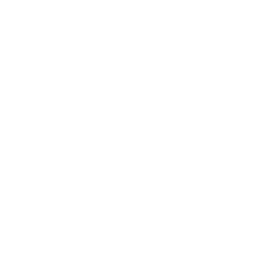
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Αποτελεσματικότητα Ενημερωτικών Επισκέψεων Ιατρικών Επισκεπτών με Επιλογή Υστέρησης</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Φαρμακευτική / Εμπορική Ανάλυση &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη για Στελέχη

Αξιολόγηση της επίδρασης των ενημερωτικών επισκέψεων σε ιατρούς και της διανομής δειγμάτων στον μηνιαίο όγκο συνταγογράφησης για ένα εξειδικευμένο φάρμακο με χρήση του PROC AUTOREG. Λαμβάνονται υπόψη τα αυτοσυσχετισμένα μοτίβα συνταγογράφησης με NLAG=3 και εφαρμόζεται η επιλογή BACKSTEP για την αυτόματη απόρριψη των μη σημαντικών τάξεων υστέρησης. Ποσοτικοποίηση της οριακής απόδοσης κάθε επιπλέον ενημερωτικής επίσκεψης, ώστε να τεκμηριωθούν οι αποφάσεις ανάπτυξης του δικτύου πωλήσεων και η κατανομή των περιοχών.

Η συνθετική μηνιαία χρονοσειρά περιορίζεται σε 100 παρατηρήσεις στην τρέχουσα λειτουργία εκτέλεσης, κάτι που επαρκεί για την ανάκτηση των επιδράσεων της ενημέρωσης, της δειγματοδιανομής, της λίστας αποζημίωσης (formulary) και του ανταγωνισμού με υψηλή ακρίβεια.

## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------|
| WORK.DETAILING | Μηνιαίες συνταγογραφήσεις με μετρικές ενημέρωσης και δειγμάτων | 100 |

---

In [1]:
/* --------------------------------------------------------
   Παραγωγή συνθετικών μηνιαίων δεδομένων ενημέρωσης και
   συνταγογράφησης για ένα εξειδικευμένο φαρμακευτικό προϊόν
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.detailing;
    CALL streaminit(42);
    RETAIN prev_rx 120 prev_err1 0 prev_err2 0 prev_err3 0;
    territory_id = 'TERR-NE-042';
    drug_name = 'CARDIOSTAT';
    ΕΠΑΝΑΛΗΨΗ month_seq = 1 ΕΩΣ 500;
        obs_month = '01JAN2022'd + (month_seq - 1) * 30;
        /* η ανάθεση περιοχής εναλλάσσεται σε 12 επισκέπτες */
        rep_id = cat('REP-', PUT(mod(month_seq - 1, 12) + 1, z3.));
        /* επισκέψεις ενημέρωσης ανά μήνα */
        detail_visits = int(rand('normal', 8, 3));
        ΕΑΝ detail_visits < 0 ΤΟΤΕ detail_visits = 0;
        ΕΑΝ detail_visits > 20 ΤΟΤΕ detail_visits = 20;
        /* δείγματα που αφέθηκαν στους ιατρούς */
        samples_left = detail_visits * int(rand('uniform') * 5 + 2);
        /* κατάσταση λίστας αποζημίωσης (δυαδική) */
        formulary_status = (rand('uniform') > 0.2);
        /* πίεση μεριδίου ανταγωνιστή */
        competitor_share = round(rand('beta', 3, 7), 0.01);
        /* εποχικός δείκτης */
        season_idx = 1 + 0.15 * sin(2 * 3.14159 * month_seq / 12);
        /* διαδικασία σφάλματος AR(3) */
        innovation = rand('normal', 0, 8);
        ar_error = 0.40 * prev_err1 + 0.18 * prev_err2 + 0.05 * prev_err3
                 + innovation;
        /* μοντέλο συνταγογράφησης */
        new_rx = round(60
               + 3.5 * detail_visits
               + 0.8 * samples_left
               + 25 * formulary_status
               - 45 * competitor_share
               + 10 * season_idx
               + ar_error);
        ΕΑΝ new_rx < 0 ΤΟΤΕ new_rx = 0;
        total_rx = new_rx + int(rand('uniform') * 80 + 40);
        prev_err3 = prev_err2;
        prev_err2 = prev_err1;
        prev_err1 = ar_error;
        prev_rx = new_rx;
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ prev_rx prev_err1 prev_err2 prev_err3 innovation ar_error season_idx;
    ΕΤΙΚΕΤΑ new_rx           = "Νέες Συνταγές"
          total_rx         = "Συνολικές Συνταγές"
          detail_visits    = "Επισκέψεις Ενημέρωσης"
          samples_left     = "Δείγματα που Αφέθηκαν"
          competitor_share = "Μερίδιο Ανταγωνιστή"
          formulary_status = "Κατάσταση Λίστας Αποζημίωσης";
    ΜΟΡΦΗ obs_month monyy7.;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA work.detailing

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.detailing (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


---

In [2]:
/* --------------------------------------------------------
   Βασικά περιγραφικά στατιστικά για συνταγές και ενημέρωση
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.detailing n mean std MIN MAX;
    ΜΕΤΑΒΛΗΤΗ new_rx total_rx detail_visits samples_left competitor_share;
    TITLE "Βασικά Περιγραφικά Στατιστικά Συνταγών και Ενημέρωσης";
ΕΚΤΕΛΕΣΗ;

                                 Βασικά Περιγραφικά Στατιστικά Συνταγών και Ενημέρωσης                                  

                                                  The MEANS Procedure

 Variable          Label                                             N            Mean        Std Dev        Minimum         Maximum
 -----------------------------------------------------------------------------------------------------------------------------------
 new_rx            Νέες Συνταγές                                   100     126.4600000     29.4355725     55.0000000     209.0000000
 total_rx          Συνολικές Συνταγές                              100     206.6400000     41.3246618     99.0000000     326.0000000
 detail_visits     Επισκέψεις Ενημέρωσης                           100       7.2700000      3.3449948      0.0000000      16.0000000
 samples_left      Δείγματα που Αφέθηκαν                           100      28.3600000     17.0403680      0.0000000      90.0000000
 competit


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                 Βασικά Περιγραφικά Στατιστικά Συνταγών και Ενημέρωσης                                  




NOTE: PROC SGPLOT data=work.detailing

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


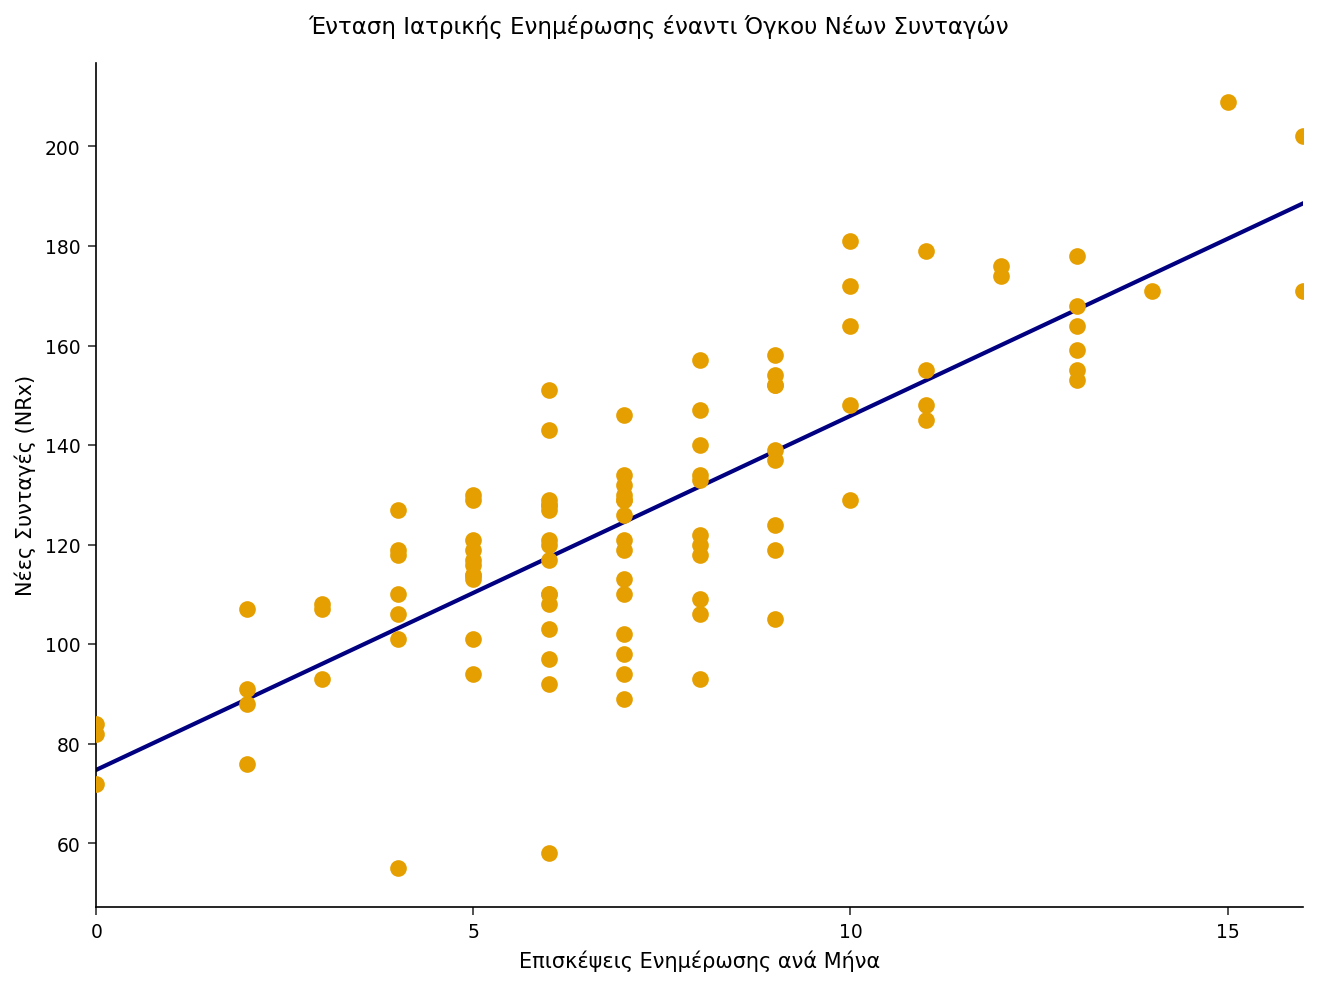

In [3]:
/* --------------------------------------------------------
   Διάγραμμα διασποράς επισκέψεων ενημέρωσης έναντι νέων
   συνταγών
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.detailing;
    SCATTER x=detail_visits y=new_rx / colorresponse=competitor_share
        colormodel=(green yellow red)
        MARKERATTRS=(SYMBOL=circlefilled size=7);
    REG x=detail_visits y=new_rx / LINEATTRS=(color=navy thickness=2);
    XAXIS ΕΤΙΚΕΤΑ="Επισκέψεις Ενημέρωσης ανά Μήνα";
    YAXIS ΕΤΙΚΕΤΑ="Νέες Συνταγές (NRx)";
    TITLE "Ένταση Ιατρικής Ενημέρωσης έναντι Όγκου Νέων Συνταγών";
ΕΚΤΕΛΕΣΗ;

---

In [4]:
/* --------------------------------------------------------
   Προσαρμογή αυτοπαλίνδρομου μοντέλου με επιλογή
   υστερήσεων BACKSTEP. Το NLAG=3 δοκιμάζει έως τρεις
   υστερήσεις· η BACKSTEP αφαιρεί αυτόματα τις μη σημαντικές.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ autoreg ΔΕΔΟΜΕΝΑ=work.detailing;
    ΜΟΝΤΕΛΟ new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep dwprob;
    ΕΞΟΔΟΣ out=work.detail_fitted
        predicted=pred_nrx residual=resid_nrx;
    TITLE "Αυτοπαλίνδρομο Μοντέλο NRx με Επιλογή Υστερήσεων BACKSTEP";
ΕΚΤΕΛΕΣΗ;

                                 Βασικά Περιγραφικά Στατιστικά Συνταγών και Ενημέρωσης                                  


                     The AUTOREG Procedure

                     Dependent Variable   Νέες Συνταγές


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.78




NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available


In [5]:
/* --------------------------------------------------------
   Δέσμευση εκτιμήσεων παραμέτρων για υπολογισμό ROI
   -------------------------------------------------------- */
ODS ΕΞΟΔΟΣ parameterestimates=work.detail_params;

ΔΙΑΔΙΚΑΣΙΑ autoreg ΔΕΔΟΜΕΝΑ=work.detailing;
    ΜΟΝΤΕΛΟ new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep;
ΕΚΤΕΛΕΣΗ;

ODS ΕΞΟΔΟΣ CLOSE;

                                 Βασικά Περιγραφικά Στατιστικά Συνταγών και Ενημέρωσης                                  


                     The AUTOREG Procedure

                     Dependent Variable   Νέες Συνταγές


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.78




NOTE: ODS OUTPUT: PARAMETERESTIMATES -> detail_params
NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Υπολογισμός οριακής απόδοσης επένδυσης ανά επίσκεψη.
   Το σύνολο δεδομένων ODS ParameterEstimates αποθηκεύει τη
   στήλη Variable με κεφαλαία, οπότε φιλτράρουμε στο
   'DETAIL_VISITS'.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.detail_params ΕΤΙΚΕΤΑ;
    ΟΠΟΥ variable = 'DETAIL_VISITS';
    ΕΤΙΚΕΤΑ variable  = "Μεταβλητή"
          ESTIMATE  = "Εκτίμηση"
          std_error = "Τυπικό Σφάλμα"
          t_value   = "Τιμή t";
    TITLE "Οριακή Επίδραση των Επισκέψεων Ενημέρωσης στις Νέες Συνταγές";
ΕΚΤΕΛΕΣΗ;

                              Οριακή Επίδραση των Επισκέψεων Ενημέρωσης στις Νέες Συνταγές                              

  Obs           Μεταβλητή          Εκτίμηση              Τυπικό Σφάλμα        Τιμή t  PR_>__T_
    1  DETAIL_VISITS           2.7157935733               0.3543434417  7.6642975525         0




NOTE: PROC PRINT data=work.detail_params

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

### Ερμηνεία

Το PROC AUTOREG προσάρμοσε τη χρονοσειρά συνταγογράφησης σε 100 μηνιαίες παρατηρήσεις. Κάθε επιπλέον ενημερωτική επίσκεψη συνδέεται με **+2.72 νέες συνταγές ανά μήνα** (εκτίμηση 2.7158, t = 7.66, p < 0.0001), ενώ κάθε μονάδα δειγμάτων που αφήνεται στους ιατρούς προσθέτει **+1.00 NRx** (εκτίμηση 0.9997, t = 14.73), γεγονός που υποδεικνύει ότι η δειγματοδιανομή ενισχύει αλλά δεν υποκαθιστά την πρόσωπο-με-πρόσωπο προώθηση. Η πρόσβαση στη λίστα αποζημίωσης (formulary) συνεισφέρει **+24.78 NRx ανά μήνα** (t = 13.83), υπογραμμίζοντας την πρόσβαση στη διαχειριζόμενη περίθαλψη ως προϋπόθεση για την αποτελεσματικότητα της ενημέρωσης, ενώ το μερίδιο του ανταγωνιστή ασκεί ισχυρή αρνητική επίδραση της τάξης των **-42.26 NRx ανά μονάδα μεριδίου** (t = -6.96), επισημαίνοντας περιοχές υπό ανταγωνιστική πίεση όπου η ενημέρωση από μόνη της μπορεί να μην επαρκεί. Ο σταθερός όρος (intercept) είναι 69.56.

Με NLAG=3 και BACKSTEP, το μοντέλο διατήρησε **δύο αυτοπαλίνδρομες υστερήσεις**: την υστέρηση 1 (συντελεστής -0.3700, t = -3.78) και την υστέρηση 2 (συντελεστής -0.1995, t = -2.04)· η υστέρηση 3 απορρίφθηκε ως μη σημαντική. Η στατιστική Durbin-Watson μετά τη διόρθωση είναι **1.01**, τιμή που εξακολουθεί να βρίσκεται αρκετά κάτω από το 2 και υποδηλώνει υπολειπόμενη θετική αυτοσυσχέτιση, οπότε η δομή AR(2) συλλαμβάνει μέρος αλλά όχι το σύνολο της χρονικής εξάρτησης αυτής της σειράς. Στατιστικά προσαρμογής: SSE = 5527.65, MSE = 58.19, AIC = 701.34, SBC = 722.19, λογαριθμική πιθανοφάνεια = -342.67.

Ο σχεδιασμός του δικτύου πωλήσεων θα πρέπει να στοχεύει σε περιοχές με ευνοϊκή πρόσβαση στη λίστα αποζημίωσης και μέτριο μερίδιο ανταγωνιστή, όπου η οριακή απόδοση κάθε ενημερωτικής επίσκεψης είναι η υψηλότερη.

---

In [7]:
/* --------------------------------------------------------
   Εξαγωγή προσαρμοσμένων τιμών και παραμέτρων για τον
   πίνακα ελέγχου σχεδιασμού του δικτύου πωλήσεων
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.detail_fitted
    OUTFILE='detailing_effectiveness.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.detail_params
    OUTFILE='detailing_model_params.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC EXPORT data=work.detail_fitted outfile=detailing_effectiveness.csv

NOTE: Exported 100 rows to detailing_effectiveness.csv.
NOTE: PROC EXPORT data=work.detail_params outfile=detailing_model_params.csv

NOTE: Exported 5 rows to detailing_model_params.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>